<a href="https://colab.research.google.com/github/anapauuu31/Portafolio_Implementacion_M2/blob/main/M2_AprendizajeM_sin_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de incumplimiento crediticio mediante Random Forest

## Análisis Exploratorio de Datos

Este análisis tiene como objetivo explorar el conjunto de datos **Default of Credit Card Clients** e identificar las principales características de los clientes y su historial de pagos antes de desarrollar un modelo de clasificación.La variable objetivo es default payment next month.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random

In [34]:
df = pd.read_excel("/content/default of credit card clients.xls")

In [35]:
df.head(1)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month


El conjunto de datos contiene información demográfica, financiera y del historial de pagos de clientes de tarjetas de crédito. Antes de realizar el análisis, se corrigieron los encabezados del archivo y se convirtieron las variables a formato numérico.

In [36]:
# Usar la primera fila como nombres de las columnas
df.columns = df.iloc[0]

# Eliminar esa primera fila porque ya se usó como encabezado
df = df.iloc[1:].reset_index(drop=True)

# Quitar el nombre que queda sobre el índice de las columnas
df.columns.name = None

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [37]:
print(df.shape)
print(df.columns.tolist())

(30000, 25)
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [38]:
df = df.apply(pd.to_numeric)

### 2. Exploración general del dataset

Se revisan las dimensiones, tipos de datos, valores faltantes, registros duplicados y cantidad de valores únicos para conocer la estructura y calidad de los datos.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [40]:
missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal de valores faltantes:", missing.sum())

Series([], dtype: int64)

Total de valores faltantes: 0


In [41]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [42]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

ID: 30000 valores únicos
LIMIT_BAL: 81 valores únicos
SEX: 2 valores únicos
EDUCATION: 7 valores únicos
MARRIAGE: 4 valores únicos
AGE: 56 valores únicos
PAY_0: 11 valores únicos
PAY_2: 11 valores únicos
PAY_3: 11 valores únicos
PAY_4: 11 valores únicos
PAY_5: 10 valores únicos
PAY_6: 10 valores únicos
BILL_AMT1: 22723 valores únicos
BILL_AMT2: 22346 valores únicos
BILL_AMT3: 22026 valores únicos
BILL_AMT4: 21548 valores únicos
BILL_AMT5: 21010 valores únicos
BILL_AMT6: 20604 valores únicos
PAY_AMT1: 7943 valores únicos
PAY_AMT2: 7899 valores únicos
PAY_AMT3: 7518 valores únicos
PAY_AMT4: 6937 valores únicos
PAY_AMT5: 6897 valores únicos
PAY_AMT6: 6939 valores únicos
default payment next month: 2 valores únicos


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### Observación

El conjunto de datos contiene 30,000 observaciones y 25 variables. No se identificaron valores faltantes ni registros duplicados, por lo que no es necesario realizar imputación o eliminación de observaciones por estos motivos.

### 3. Análisis de la variable objetivo

La variable `default payment next month` indica si el cliente presentó incumplimiento de pago.

Se analiza su distribución para determinar si existe un desbalance entre las clases.

In [44]:
target = "default payment next month"

print(df[target].value_counts())

print("\nPorcentajes:")
print(df[target].value_counts(normalize=True) * 100)

default payment next month
0    23364
1     6636
Name: count, dtype: int64

Porcentajes:
default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


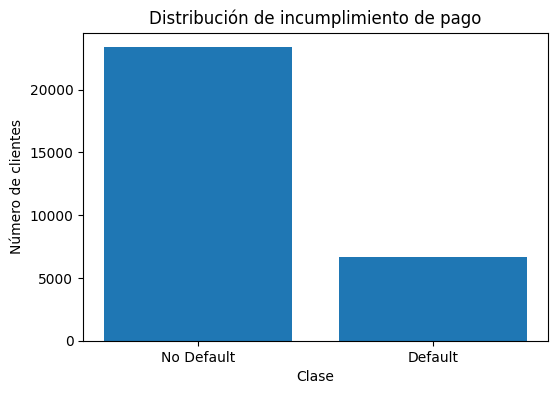

In [45]:
counts = df[target].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Default", "Default"],
    counts.values
)

plt.title("Distribución de incumplimiento de pago")
plt.xlabel("Clase")
plt.ylabel("Número de clientes")

plt.show()

In [46]:
df[target].value_counts()
df[target].value_counts(normalize=True) * 100

,proportion
default payment next month,
0,77.88
1,22.12


### Observación

El 77.88% de los clientes pertenece a la clase **No Default**, mientras que el 22.12% pertenece a **Default**. Por lo tanto, existe un desbalance entre las clases.

Esto deberá considerarse durante la evaluación del modelo, ya que la exactitud (accuracy) por sí sola podría dar una impresión engañosa de su desempeño. Será importante complementar esta métrica con la matriz de confusión, precision, recall y F1-score.

### 4. Análisis de variables categóricas

Las variables sex, education y marriage representan características categóricas codificadas numéricamente. Se revisan sus distribuciones para identificar las categorías presentes en el dataset.

In [47]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


### Observación

Las variables categóricas se encuentran codificadas numéricamente. Se observa que education y marriage contienen categorías adicionales a las principales, por lo que su codificación deberá considerarse durante la etapa de preprocesamiento antes de entrenar el modelo.

### 5. Análisis del historial de pagos

Las variables PAY_0, PAY_2, PAY_3, PAY_4, PAY_5 y PAY_6 representan el estado de pago del cliente en diferentes meses.

Se revisan los valores presentes en estas variables antes de analizar su relación con el incumplimiento.

In [48]:
payment_status = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in payment_status:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

### 6. Análisis de variables numéricas

Se analiza la distribución de algunas variables numéricas relevantes para comprender las características generales de los clientes.

En particular, se examinan el límite de crédito LIMIT_BAL y la edad AGE mediante histogramas, con el objetivo de observar su distribución, concentración y posibles valores extremos.

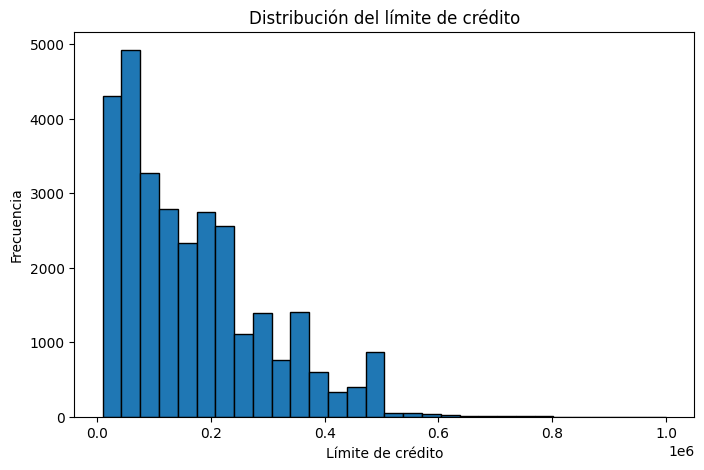

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(df["LIMIT_BAL"], bins=30, edgecolor="black")

plt.title("Distribución del límite de crédito")
plt.xlabel("Límite de crédito")
plt.ylabel("Frecuencia")

plt.show()

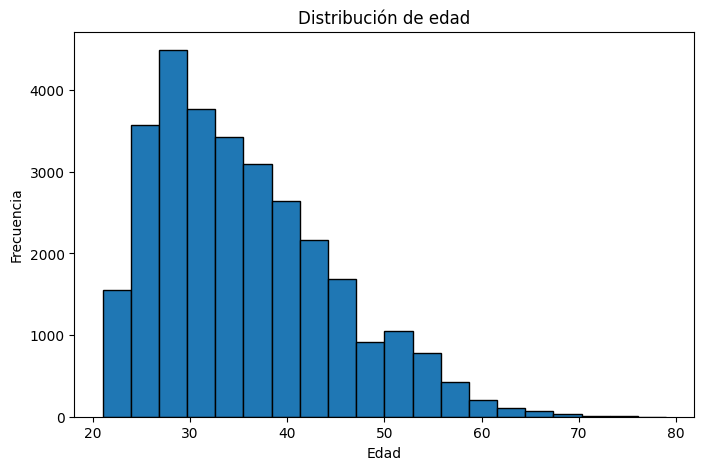

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(df["AGE"], bins=20, edgecolor="black")

plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

### Observación

El límite de crédito presenta una distribución asimétrica hacia la derecha, con una mayor concentración de clientes en límites relativamente bajos y una menor frecuencia conforme aumenta el límite disponible.

La edad también presenta una distribución asimétrica hacia la derecha. La mayor concentración de clientes se encuentra en edades adultas jóvenes, con una mediana de 34 años y una disminución progresiva en la frecuencia hacia edades mayores.

### 7. Relación entre el historial de pago y el incumplimiento

El historial de pagos puede aportar información relevante para identificar el riesgo de incumplimiento de un cliente.

A continuación, se analiza el porcentaje de clientes que presentaron default según su estado de pago más reciente PAY_0. Esto permite observar si existen diferencias en la proporción de incumplimiento entre los distintos estados de pago.

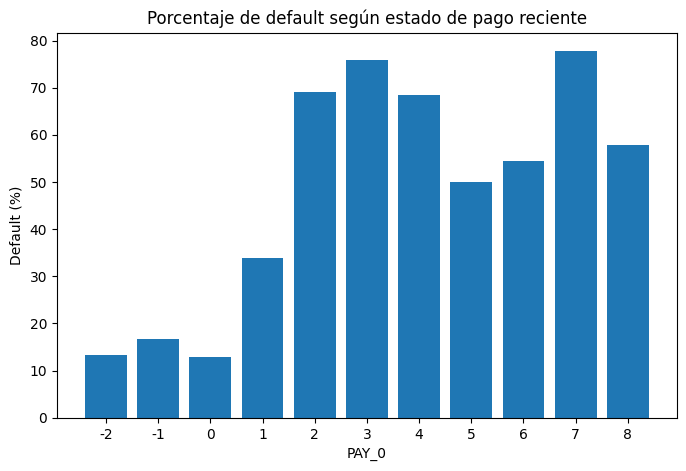

In [51]:
default_by_pay0 = (
    df.groupby("PAY_0")[target]
    .mean() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    default_by_pay0.index.astype(str),
    default_by_pay0.values
)

plt.title("Porcentaje de default según estado de pago reciente")
plt.xlabel("PAY_0")
plt.ylabel("Default (%)")

plt.show()

### Observación

Se observa una relación importante entre el estado de pago reciente PAY_0 y el incumplimiento del mes siguiente. Los clientes asociados con estados de mayor retraso presentan, en general, porcentajes de default considerablemente superiores.

Este comportamiento sugiere que el historial reciente de pagos puede ser una variable relevante para la predicción del incumplimiento.

### 8. Análisis de correlación

Se analiza la correlación entre las variables numéricas para identificar relaciones lineales entre las características financieras y la variable objetivo.

La variable ID se excluye del análisis debido a que funciona únicamente como identificador de cada cliente.

In [52]:
df_corr = df.drop(columns=["ID"])

corr = df_corr.corr()

target_corr = (
    corr[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_corr

,default payment next month
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
LIMIT_BAL,-0.153520
PAY_AMT1,-0.072929
PAY_AMT2,-0.058579
PAY_AMT4,-0.056827


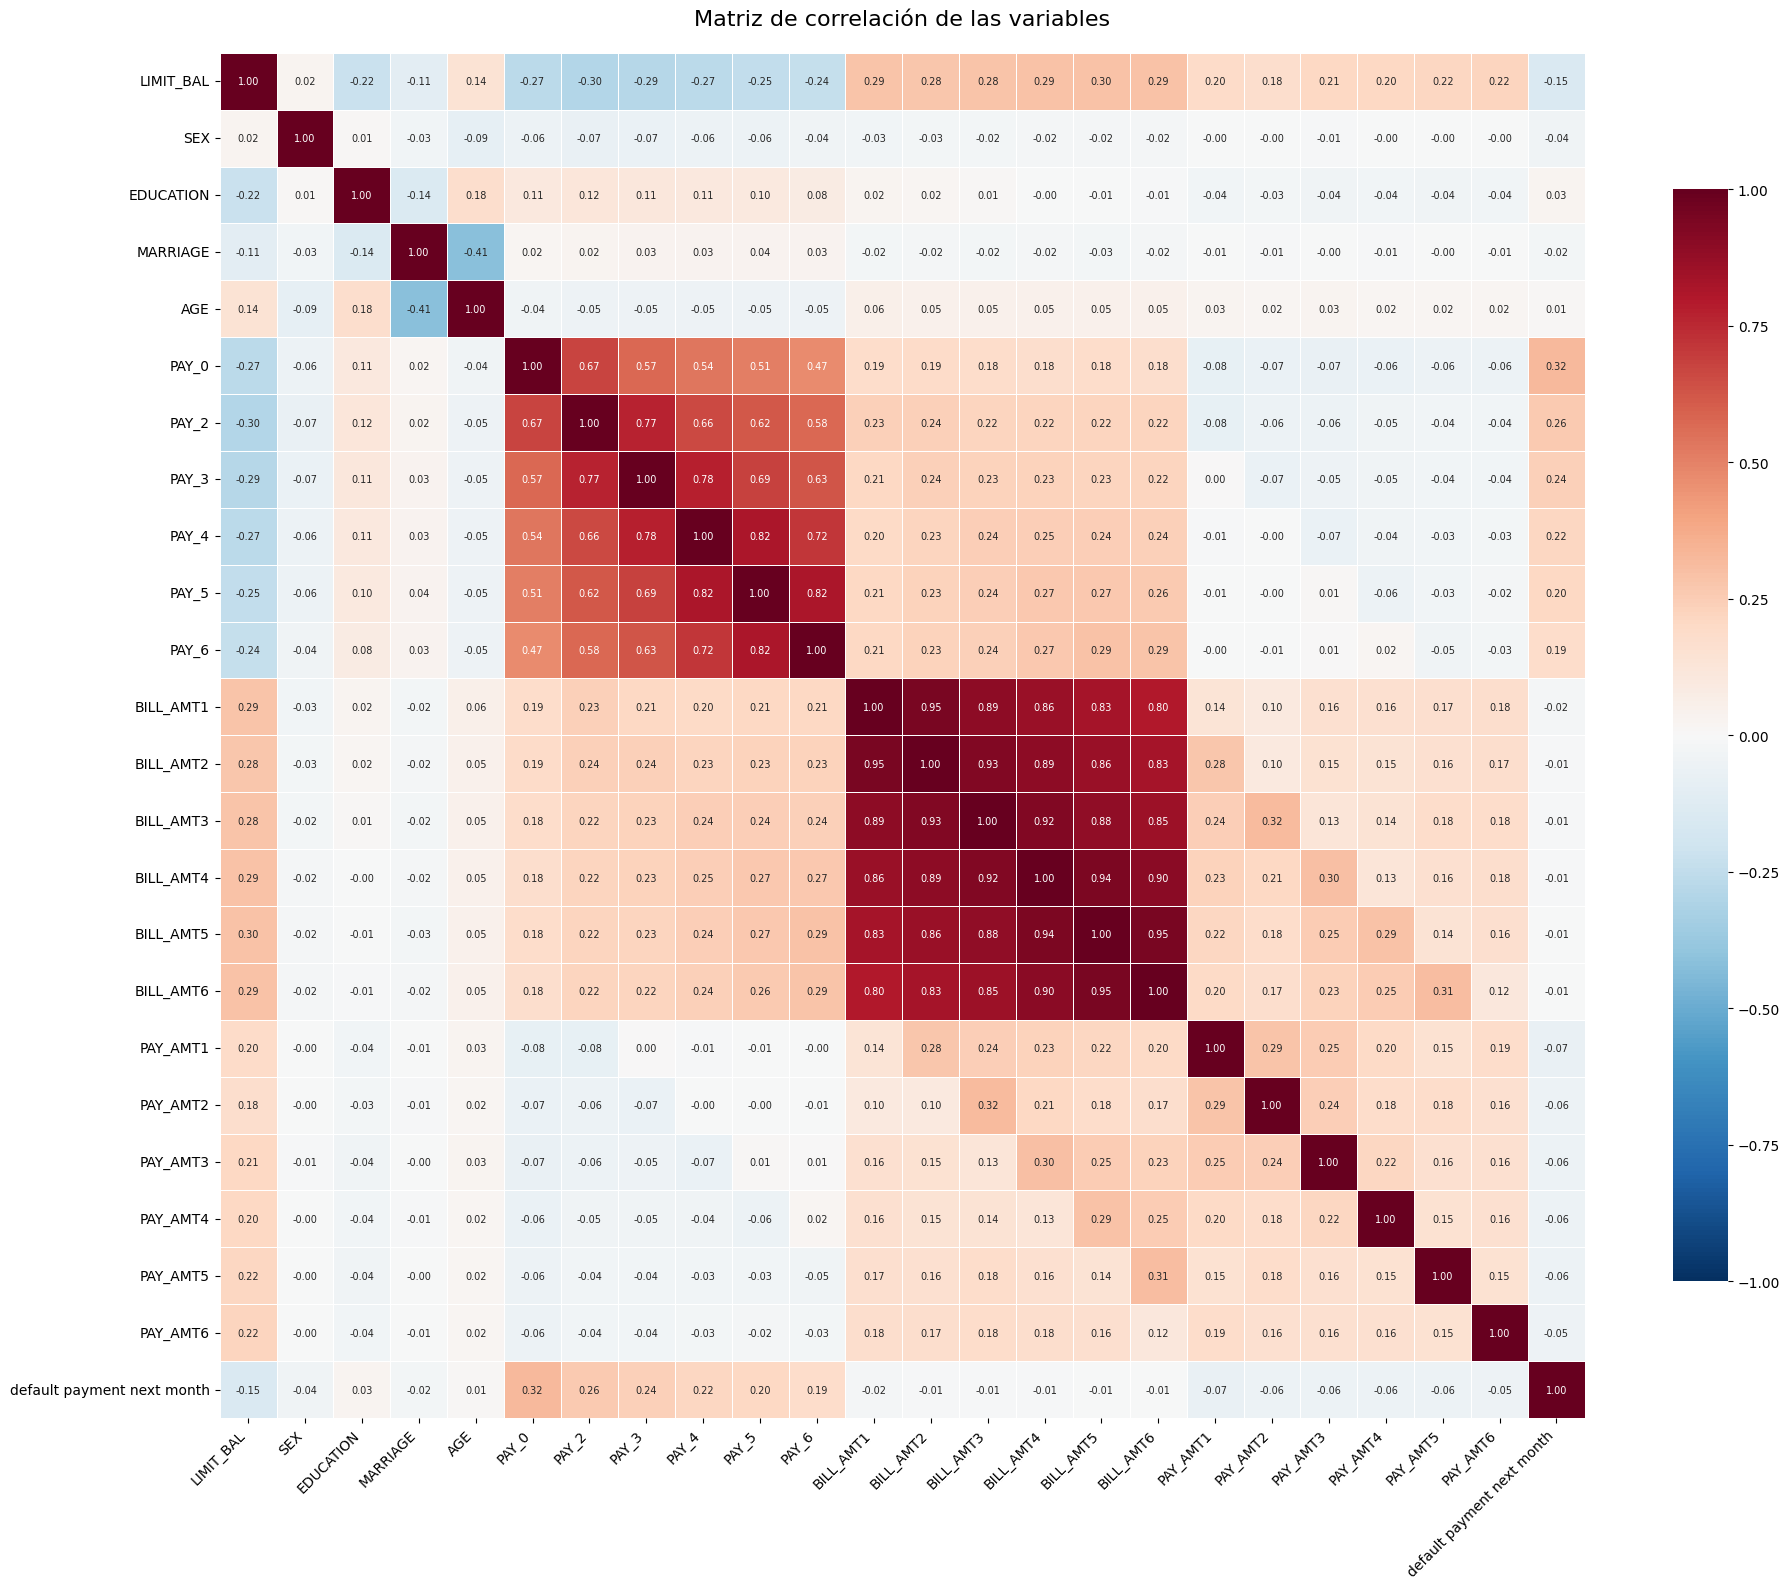

In [53]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    square=True,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Matriz de correlación de las variables",
    fontsize=16,
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Observación

Las variables relacionadas con el historial de pago presentan las mayores correlaciones lineales con la variable objetivo. PAY_0 muestra la asociación más alta (0.325), seguida por los estados de pago de meses anteriores.

Por otro lado, LIMIT_BAL presenta una correlación negativa de -0.154, mientras que variables como edad, sexo, educación, estado civil y montos facturados muestran correlaciones lineales considerablemente menores.

Sin embargo, una correlación lineal baja no implica necesariamente que una variable carezca de valor predictivo.

## 9. Preprocesamiento de datos



Eliminamos el ID para evitar que el modelo aprenda splits basados en él

In [54]:
df_model = df.drop(columns=["ID"])

df_model.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


En la documentación original, las categorías principales son 1 = graduate school, 2 = university, 3 = high school y 4 = others; los códigos 0, 5 y 6 no están documentados como categorías principales. Para el modelo agrupamos los códigos especiales en 4 = Others

In [55]:
df_model["EDUCATION"] = df_model["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

df_model["EDUCATION"].value_counts().sort_index()

,count
EDUCATION,
1,10585
2,14030
3,4917
4,468


Los registros con código 0 en marriage se agrupan dentro de la categoría "Others", conservando las observaciones sin crear una categoría adicional con muy pocos registros.

In [56]:
df_model["MARRIAGE"] = df_model["MARRIAGE"].replace({
    0: 3
})

df_model["MARRIAGE"].value_counts().sort_index()

,count
MARRIAGE,
1,13659
2,15964
3,377


### Separación de variables predictoras y variable objetivo

Las variables predictoras se almacenan en X, mientras que la variable default payment next month se almacena en y. El modelo utilizará las características contenidas en X para predecir si un cliente presentará incumplimiento de pago.

No se aplica normalización ni estandarización a las variables numéricas. Random Forest se basa en árboles de decisión que realizan divisiones mediante umbrales sobre cada característica, por lo que no requiere que las variables se encuentren en la misma escala.

In [57]:
target = "default payment next month"

X = df_model.drop(columns=[target])
y = df_model[target]

In [58]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 23)
Dimensiones de y: (30000,)


In [59]:
np.random.seed(42)

indices_0 = np.where(y.values == 0)[0]
indices_1 = np.where(y.values == 1)[0]

np.random.shuffle(indices_0)
np.random.shuffle(indices_1)

split_0 = int(len(indices_0) * 0.7)
split_1 = int(len(indices_1) * 0.7)

train_indices = np.concatenate([
    indices_0[:split_0],
    indices_1[:split_1]
])

test_indices = np.concatenate([
    indices_0[split_0:],
    indices_1[split_1:]
])

np.random.shuffle(train_indices)
np.random.shuffle(test_indices)

X_train = X.iloc[train_indices].reset_index(drop=True)
X_test = X.iloc[test_indices].reset_index(drop=True)

y_train = y.iloc[train_indices].reset_index(drop=True)
y_test = y.iloc[test_indices].reset_index(drop=True)

In [60]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (20999, 23)
X_test: (9001, 23)
y_train: (20999,)
y_test: (9001,)


In [61]:
print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)


Distribución en entrenamiento:
default payment next month
0    77.879899
1    22.120101
Name: proportion, dtype: float64

Distribución en prueba:
default payment next month
0    77.880236
1    22.119764
Name: proportion, dtype: float64


In [62]:
train_data = X_train.copy()
train_data[target] = y_train

test_data = X_test.copy()
test_data[target] = y_test

train_data.to_csv("credit_default_train.csv", index=False)
test_data.to_csv("credit_default_test.csv", index=False)

## 10. Implementación del algoritmo Random Forest

En esta sección se implementa el algoritmo Random Forest sin utilizar frameworks de machine learning.

El modelo se construye a partir de varios árboles de decisión. Cada árbol se entrena con una muestra aleatoria de los datos mediante bootstrap y selecciona un subconjunto aleatorio de características para realizar las divisiones.

Para elegir las divisiones de cada árbol se utiliza la entropía y la ganancia de información. Finalmente, las predicciones de todos los árboles se combinan mediante voto mayoritario para obtener la predicción final.

In [63]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        self.max_features = self.max_features or len(X[0])
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y, depth=0):
        n_samples, n_feats = len(X), len(X[0])

        if depth >= self.max_depth or n_samples < self.min_samples_split or len(set(y)) == 1:
            return Node(value=max(set(y), key=y.count))

        feat_idxs = random.sample(
            range(n_feats),
            min(n_feats, self.max_features)
        )

        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        if best_feat is None:
            return Node(value=max(set(y), key=y.count))

        left_idxs = [
            i for i, row in enumerate(X)
            if row[best_feat] <= best_thresh
        ]

        right_idxs = [
            i for i, row in enumerate(X)
            if row[best_feat] > best_thresh
        ]

        left = self._build_tree(
            [X[i] for i in left_idxs],
            [y[i] for i in left_idxs],
            depth + 1
        )

        right = self._build_tree(
            [X[i] for i in right_idxs],
            [y[i] for i in right_idxs],
            depth + 1
        )

        return Node(
            feature=best_feat,
            threshold=best_thresh,
            left=left,
            right=right
        )

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in feat_idxs:
            thresholds = set(row[feat_idx] for row in X)

            for thr in thresholds:
                gain = self._information_gain(X, y, feat_idx, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr

        return split_idx, split_thresh

    def _information_gain(self, X, y, feat_idx, thr):
        parent_entropy = self._entropy(y)

        left_y = [
            y[i] for i, row in enumerate(X)
            if row[feat_idx] <= thr
        ]

        right_y = [
            y[i] for i, row in enumerate(X)
            if row[feat_idx] > thr
        ]

        if not left_y or not right_y:
            return 0

        n = len(y)
        n_l = len(left_y)
        n_r = len(right_y)

        e_l = self._entropy(left_y)
        e_r = self._entropy(right_y)

        return parent_entropy - (
            (n_l / n) * e_l +
            (n_r / n) * e_r
        )

    def _entropy(self, y):
        hist = [y.count(c) for c in set(y)]

        return -sum(
            (c / len(y)) * math.log2(c / len(y))
            for c in hist if c > 0
        )

    def predict(self, X):
        return [
            self._traverse_tree(x, self.root)
            for x in X
        ]

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)

        return self._traverse_tree(x, node.right)

class RandomForest:
    def __init__(self, n_trees=10, max_depth=10,
                 min_samples_split=2, max_features=None):

        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []

        for _ in range(self.n_trees):

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )

            # Bootstrap
            indices = [
                random.randint(0, len(X) - 1)
                for _ in range(len(X))
            ]

            X_sample = [X[i] for i in indices]
            y_sample = [y[i] for i in indices]

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = [
            tree.predict(X)
            for tree in self.trees
        ]

        sample_preds = zip(*tree_preds)

        return [
            max(set(sample), key=sample.count)
            for sample in sample_preds
        ]

## 11. Evaluación del modelo

El modelo se evalúa utilizando el conjunto de prueba, el cual no fue utilizado durante el entrenamiento.

Debido al desbalance de clases presente en el dataset, además de accuracy se utilizan precision, recall, F1-score y la matriz de confusión para evaluar el desempeño del modelo.

In [66]:
# Entrenar modelo
model = RandomForest(
    n_trees=5,
    max_depth=6,
    min_samples_split=20,
    max_features=5
)

model.fit(X_train_sample, y_train_sample)

# Predicciones
y_pred = model.predict(X_test_list)

# Métricas
matrix = confusion_matrix(y_test_list, y_pred)

accuracy = accuracy_score(y_test_list, y_pred)
precision = precision_score(y_test_list, y_pred)
recall = recall_score(y_test_list, y_pred)
f1 = f1_score(y_test_list, y_pred)

print("Matriz de confusión:")
print(matrix)

print("\nAccuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Matriz de confusión:
[[6562  448]
 [1353  638]]

Accuracy: 0.7999
Precision: 0.5875
Recall: 0.3204
F1-score: 0.4147
